# ❤️ Heart Disease Risk Prediction using SVM

A machine learning project that predicts a patient's heart disease risk (High/Low) using a Support Vector Machine (SVM), tuned with GridSearchCV.

**Tech stack:** Python, pandas, NumPy, scikit-learn, matplotlib
**Result:** See evaluation metrics below (accuracy, precision, recall, F1-score)

## 1. Setup & Load Data
Import required libraries and load the heart disease dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## 2. Exploratory Data Analysis
Visualize feature distributions and examine the relationship between chest pain type (`cp`) and maximum heart rate (`thalachh`) across risk groups.

In [1]:
df = pd.read_csv("heart.csv")
df.head(11)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trtbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalachh'}>],
       [<Axes: title={'center': 'exng'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slp'}>, <Axes: title={'center': 'caa'}>],
       [<Axes: title={'center': 'thall'}>,
        <Axes: title={'center': 'output'}>, <Axes: >, <Axes: >]],
      dtype=object)

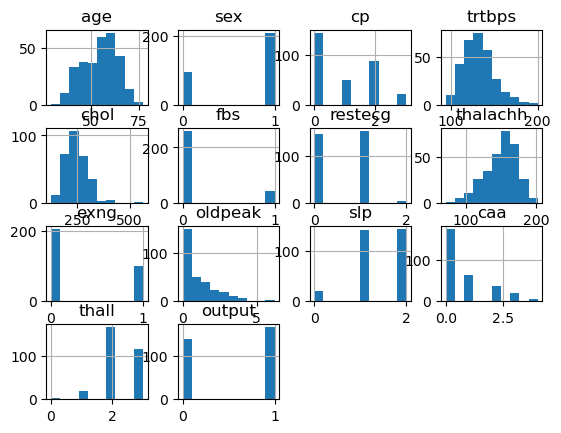

In [2]:
df.hist()

<Figure size 800x600 with 0 Axes>

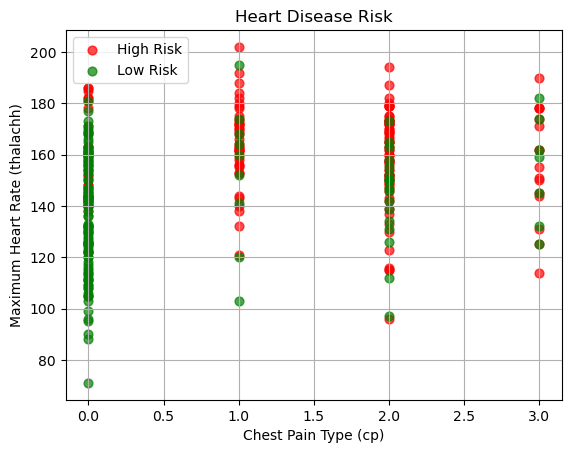

In [3]:
plt.figure(figsize=(8,6))

ax = df[df['output']==1].plot(
    kind='scatter',
    x='cp',
    y='thalachh',
    color='red',
    label='High Risk',
    alpha=0.7,
    s=40
)

df[df['output']==0].plot(
    kind='scatter',
    x='cp',
    y='thalachh',
    color='green',
    label='Low Risk',
    alpha=0.7,
    s=40,
    ax=ax
)

plt.title("Heart Disease Risk")
plt.xlabel("Chest Pain Type (cp)")
plt.ylabel("Maximum Heart Rate (thalachh)")
plt.grid(True)
plt.show()

## 3. Data Preprocessing
Separate features and target, split the data into training and test sets (80/20, stratified), and standardize features using `StandardScaler`.

In [4]:
X = df.drop('output', axis=1)
y = df['output']

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=4,
    stratify=y
)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4. Model Training & Hyperparameter Tuning
Train an SVM classifier and use `GridSearchCV` to find the best combination of `C`, `gamma`, and `kernel`.

In [7]:
from sklearn import svm
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

params = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'linear']
}

grid = GridSearchCV(SVC(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}


In [8]:
clf = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.8221088435374149


## 5. Model Evaluation
Generate predictions on the test set and evaluate performance using accuracy, confusion matrix, classification report, precision, recall, and F1-score.

In [9]:
yhat = clf.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, yhat))
print(confusion_matrix(y_test, yhat))
print(classification_report(y_test, yhat))

from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(y_test, yhat))
print("Recall:", recall_score(y_test, yhat))

Accuracy: 0.8524590163934426
[[22  6]
 [ 3 30]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

Precision: 0.8333333333333334
Recall: 0.9090909090909091


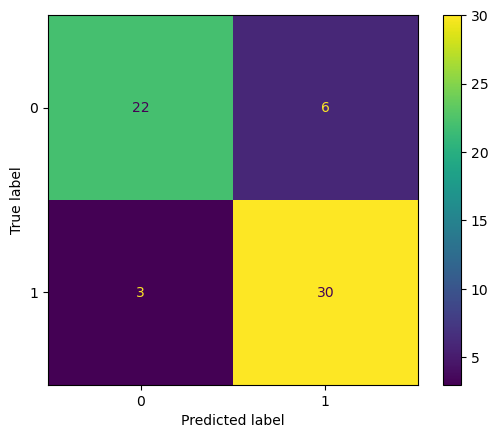

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test)
plt.show()

In [12]:
from sklearn.metrics import f1_score
f1_score(y_test, yhat, average='weighted')

0.8514907408652618

## 🏁 Conclusion
The tuned SVM model provides a reliable classifier for identifying patients at high risk of heart disease, demonstrating a full ML workflow: EDA → preprocessing → hyperparameter tuning → evaluation.